## Section 1 — Setup and Imports

In [1]:
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install torch
# !pip install torchvision

In [2]:
import os, sys, json
import numpy as np
import torch

PROJECT_PATH = "/Users/manish/Documents/GitHub/Crop-disease-detection"
SRC_PATH = os.path.join(PROJECT_PATH, "src")

# Add project folder to Python path so we can import from pipeline/
if PROJECT_PATH not in sys.path:
    sys.path.insert(0, PROJECT_PATH)
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

# Import our pipeline modules
from config  import CFG as CFG
from data_loader import prepare_data
from model_builder import build_model
from trainer  import train_model
from evaluator import plot_history

# Create output folders
os.makedirs(CFG["MODELS_DIR"],  exist_ok=True)
os.makedirs(CFG["RESULTS_DIR"], exist_ok=True)

print(f"Device  : {CFG['DEVICE']}")
print(f"Model  : {CFG['MODELS']}")


Device  : mps
Model  : ['MobileNetV2']


## Section 2 - Baseline (Clean Image)

In [3]:
print(CFG.keys())

dict_keys(['CLEAN_IMAGES', 'CLEAN_LABELS', 'DROP_IMAGES', 'DROP_LABELS', 'DROP_IMAGES_1', 'DROP_LABELS_1', 'MODELS_DIR', 'RESULTS_DIR', 'DEVICE', 'NUM_CLASSES', 'BATCH_SIZE', 'NUM_WORKERS', 'TEST_SIZE', 'VAL_SIZE', 'SEED', 'IMG_MEAN', 'IMG_STD', 'MODELS', 'LR', 'WEIGHT_DECAY', 'EPOCHS', 'PATIENCE', 'SETTINGS', 'MAX_CLASS_WEIGHT'])


In [ ]:
# Load the clean dataset
print("Loading clean dataset")

loaders_baseline, test_labels, class_names, encoder = prepare_data(
    CFG["CLEAN_IMAGES"],
    CFG["CLEAN_LABELS"],
    CFG,
)

Loading clean dataset
  54,305 images  |  38 classes
  Train 34,755  Val 8,689  Test 10,861


: 


  MobileNetV2


  Total parameters : 2,272,550

Epoch [ 1/20]  Train Loss: 0.8905  Train Acc: 84.76%  Val Acc: 97.71%  
  ---------------------------------------------------------------------------
Epoch [ 2/20]  Train Loss: 0.0978  Train Acc: 97.75%  Val Acc: 98.56%  
  ---------------------------------------------------------------------------
Epoch [ 3/20]  Train Loss: 0.0574  Train Acc: 98.76%  Val Acc: 99.22%  
  ---------------------------------------------------------------------------
Epoch [ 4/20]  Train Loss: 0.0400  Train Acc: 99.04%  Val Acc: 99.55%  
  ---------------------------------------------------------------------------
Epoch [ 5/20]  Train Loss: 0.0280  Train Acc: 99.30%  Val Acc: 99.45%  
  ---------------------------------------------------------------------------
Epoch [ 6/20]  Train Loss: 0.0243  Train Acc: 99.39%  Val Acc: 99.59%  
  ---------------------------------------------------------------------------
Epoch [ 7/20]  Train Loss: 0.0219  Train Acc: 99.47%  Val Acc: 99.62

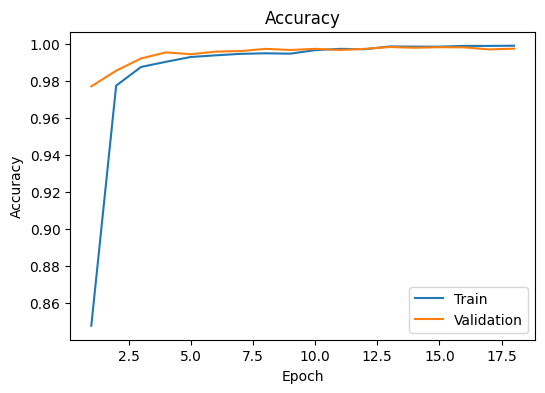

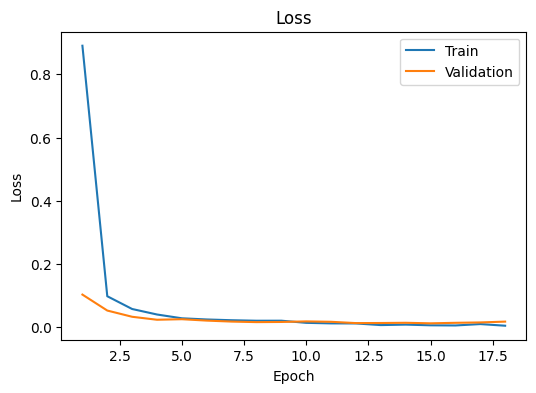

: 

In [ ]:
# Train all 3 models — same 4 steps for every model
# build - train - evaluate - plot curves

for model_name in CFG["MODELS"]:

    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")

    # Step 1: Build model (load ImageNet weights, freeze base, add our head)
    bundle = build_model(model_name, CFG)

    # Step 2: Train (Phase 1: head only → Phase 2: fine-tune base layers)
    trained_model, history = train_model(bundle, loaders_baseline, "baseline", CFG)

    # Step 4: Plot accuracy and loss curves
    plot_history(model_name, "baseline", CFG)

    # Free memory before training the next model
    del trained_model, bundle
    torch.mps.empty_cache() if CFG["DEVICE"] == "mps" else None


## Section 2 - Droplet Images

In [ ]:
print("Loading droplet dataset...")
loaders_distorted, test_labels_distorted, class_names, encoder = prepare_data(
    CFG["DROP_IMAGES"], CFG["DROP_LABELS"], CFG,
)


Loading droplet dataset...


  54,305 images  |  38 classes



  MobileNetV2 —  Droplet Dataset
  Total parameters    : 2,272,550

Epoch [ 1/20]  Train Loss: 0.9614  Train Acc: 82.50%  Val Acc: 96.62%  
  ---------------------------------------------------------------------------
Epoch [ 2/20]  Train Loss: 0.1218  Train Acc: 97.06%  Val Acc: 97.87%  
  ---------------------------------------------------------------------------
Epoch [ 3/20]  Train Loss: 0.0728  Train Acc: 98.42%  Val Acc: 98.55%  
  ---------------------------------------------------------------------------
Epoch [ 4/20]  Train Loss: 0.0467  Train Acc: 98.81%  Val Acc: 99.36%  
  ---------------------------------------------------------------------------
Epoch [ 5/20]  Train Loss: 0.0361  Train Acc: 99.07%  Val Acc: 99.32%  
  ---------------------------------------------------------------------------
Epoch [ 6/20]  Train Loss: 0.0261  Train Acc: 99.31%  Val Acc: 99.46%  
  ---------------------------------------------------------------------------
Epoch [ 7/20]  Train Loss: 0.02

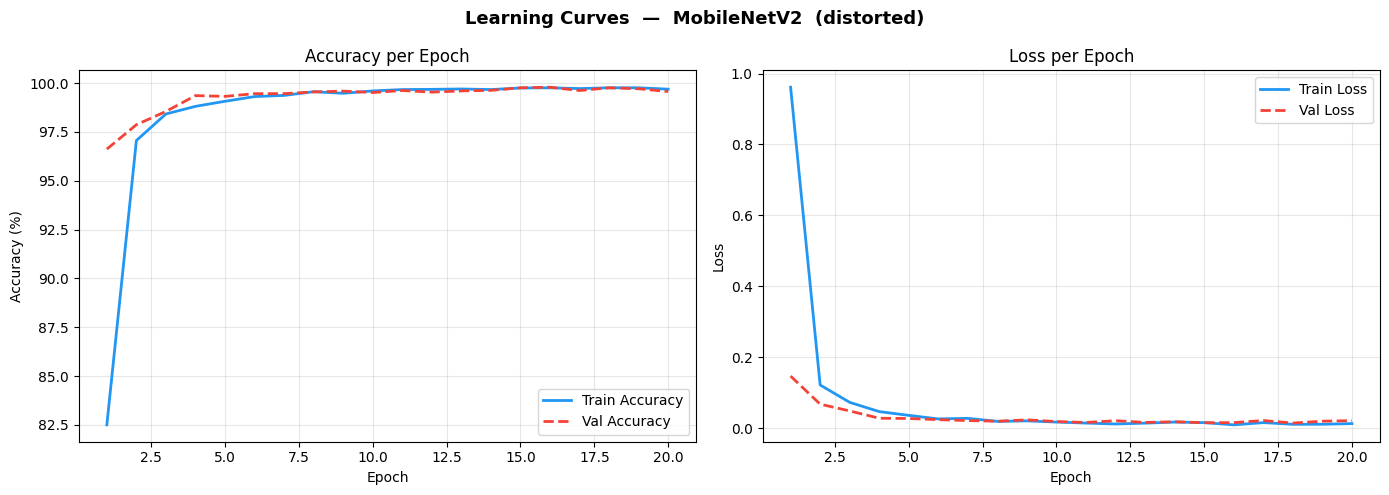

  Curve saved → /Users/manish/Documents/Semister 2/7. Project/Aarti Data Droplet/results/curve_MobileNetV2_distorted.png


In [ ]:
for model_name in CFG["MODELS"]:

    print(f"\n{'='*55}")
    print(f"  {model_name} —  Droplet Dataset")
    print(f"{'='*55}")

    # Step 1: Build model (load ImageNet weights, freeze base, add our head)
    bundle = build_model(model_name, CFG)

    # Step 2: Train (Phase 1: head only → Phase 2: fine-tune base layers)
    trained_model, history = train_model(bundle, loaders_distorted, "distorted", CFG)

    # Step 4: Plot accuracy and loss curves
    plot_history(model_name, "distorted", CFG)

    # Free memory before training the next model
    del trained_model, bundle
    torch.mps.empty_cache() if CFG["DEVICE"] == "mps" else None


In [ ]:
print("Loading second droplet dataset...")
loaders_distorted2, test_labels_d2, class_names, encoder = prepare_data(
    CFG["DROP_IMAGES_1"],
    CFG["DROP_LABELS_1"],
    CFG,
)

Loading second droplet dataset...
  54,305 images  |  38 classes
  Train 34,755  Val 8,689  Test 10,861



  MobileNetV2 —  Droplet Dataset
  Total parameters    : 2,272,550

Epoch [ 1/20]  Train Loss: 1.0479  Train Acc: 80.96%  Val Acc: 96.06%  
  ---------------------------------------------------------------------------
Epoch [ 2/20]  Train Loss: 0.1422  Train Acc: 96.55%  Val Acc: 97.96%  
  ---------------------------------------------------------------------------
Epoch [ 3/20]  Train Loss: 0.0738  Train Acc: 98.12%  Val Acc: 98.78%  
  ---------------------------------------------------------------------------
Epoch [ 4/20]  Train Loss: 0.0494  Train Acc: 98.75%  Val Acc: 99.06%  
  ---------------------------------------------------------------------------
Epoch [ 5/20]  Train Loss: 0.0420  Train Acc: 98.91%  Val Acc: 99.22%  
  ---------------------------------------------------------------------------
Epoch [ 6/20]  Train Loss: 0.0331  Train Acc: 99.23%  Val Acc: 99.01%  
  ---------------------------------------------------------------------------
Epoch [ 7/20]  Train Loss: 0.02

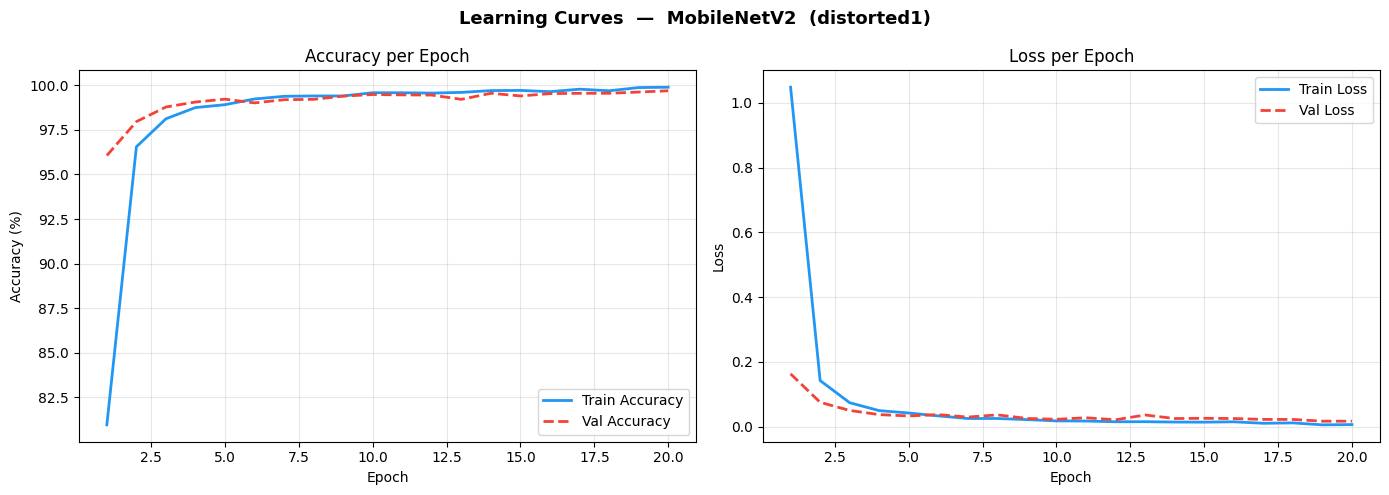

  Curve saved → /Users/manish/Documents/Semister 2/7. Project/Aarti Data Droplet/results/curve_MobileNetV2_distorted1.png


In [ ]:
for model_name in CFG["MODELS"]:

    print(f"\n{'='*55}")
    print(f"  {model_name} —  Droplet Dataset")
    print(f"{'='*55}")

    # Step 1: Build model (load ImageNet weights, freeze base, add our head)
    bundle = build_model(model_name, CFG)

    # Step 2: Train (Phase 1: head only → Phase 2: fine-tune base layers)
    trained_model, history = train_model(bundle, loaders_distorted2, "distorted1", CFG)

    # Step 4: Plot accuracy and loss curves
    plot_history(model_name, "distorted1", CFG)

    # Free memory before training the next model
    del trained_model, bundle
    torch.mps.empty_cache() if CFG["DEVICE"] == "mps" else None


In [3]:
import hashlib
from data_loader import prepare_data

# Load full loaders (needed to access both train and test splits)
print("Loading full baseline loaders for leakage check...")
loaders_baseline, _, _, _ = prepare_data(
    CFG["CLEAN_IMAGES"], CFG["CLEAN_LABELS"], CFG
)

def get_hash(img):
    return hashlib.md5(img.tobytes()).hexdigest()

train_hashes = set()

for img, _ in loaders_baseline["train"].dataset:
    img = (img.numpy() * 255).astype("uint8")
    train_hashes.add(get_hash(img))

test_hashes = set()

for img, _ in loaders_baseline["test"].dataset:
    img = (img.numpy() * 255).astype("uint8")
    test_hashes.add(get_hash(img))

duplicates = train_hashes.intersection(test_hashes)

print("Baseline duplicate images:", len(duplicates))

Loading full baseline loaders for leakage check...
  54,305 images  |  38 classes
  Train 34,755  Val 8,689  Test 10,861
Baseline duplicate images: 0
